# Phase 4: Unsupervised Learning (Corrected)
In this phase, we group our users into behavioral "Personas" using K-Means clustering.
Steps:
1. Feature Preprocessing (Log Transform & StandardScaler)
2. Determining K (Elbow Method & Silhouette)
3. K-Means Clustering & PCA visualization
4. Persona Profiling (Z-scores Heatmap)
5. Exporting Model and Data


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib

import warnings
warnings.filterwarnings('ignore')


In [9]:
# Load Data
df = pd.read_csv('../data/processed/user_profiles.csv')

# Features we engineered in Phase 3
features = [
    'completion_ratio', 
    'session_intensity', 
    'diversity_score',
    'abandonment_rate', 
    'competitive_index', 
    'exploration_score', 
    'narrative_affinity'
]

X = df[features].copy()
print(f"Data shape: {X.shape}")


Data shape: (11324, 7)


In [10]:
# 1. Preprocessing: Log Transform & Standardization

# Handle extreme outliers in session_intensity with a log transform
X['session_intensity'] = np.log1p(X['session_intensity'])

# Scale features to have mean=0, variance=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')


['../models/scaler.pkl']

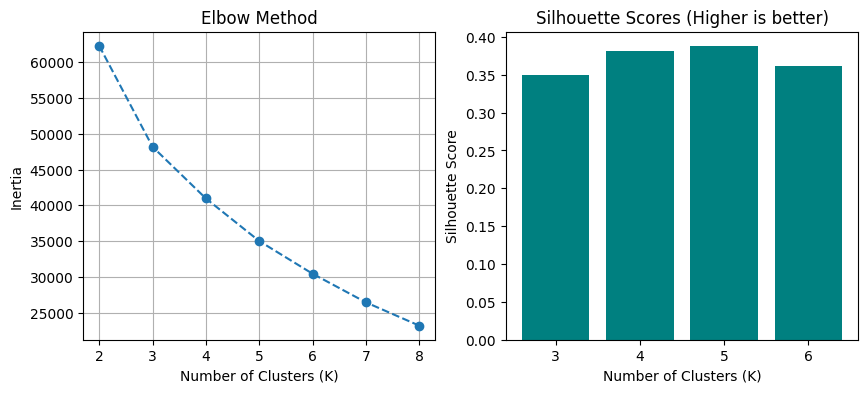

Silhouette Score for K=3: 0.349
Silhouette Score for K=4: 0.381
Silhouette Score for K=5: 0.387
Silhouette Score for K=6: 0.362


In [16]:
# 2. Elbow Method & Silhouette Score
inertia = []
sil_scores = {}
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    
    # Calculate Silhouette Score for k > 2
    if k >= 3 and k <= 6:
        sil_scores[k] = silhouette_score(X_scaled, labels)

# Plot Elbow
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)

# Plot Silhouette
plt.subplot(1, 2, 2)
plt.bar(sil_scores.keys(), sil_scores.values(), color='teal')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores (Higher is better)')
plt.show()

for k, score in sil_scores.items():
    print(f"Silhouette Score for K={k}: {score:.3f}")


In [17]:
# 3. K-Means Clustering
# Automatically select the K with the highest Silhouette score between 3 and 6
optimal_k = max(sil_scores, key=sil_scores.get)
print(f"\nSelected Optimal K: {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Save the trained model
joblib.dump(kmeans, '../models/kmeans_model.pkl')



Selected Optimal K: 5


['../models/kmeans_model.pkl']

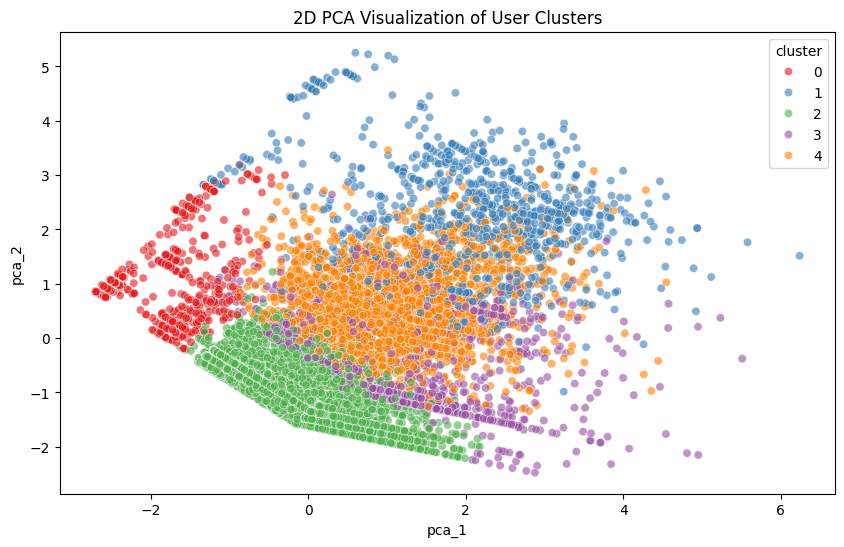

Explained variance by 2 PCA components: 54.58%


In [18]:
# PCA for 2D Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='pca_1', y='pca_2', 
    hue='cluster', 
    palette='Set1', 
    data=df, 
    alpha=0.6
)
plt.title('2D PCA Visualization of User Clusters')
plt.show()

print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum():.2%}")


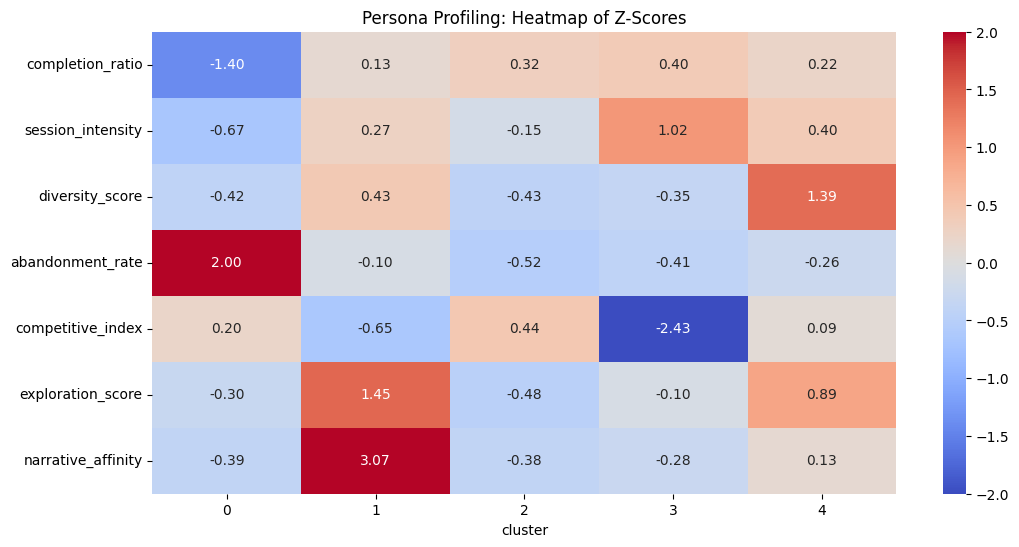

In [14]:
# 4. Persona Profiling using Z-scores
# Using kmeans.cluster_centers_ gives us the standard scaled values (Z-scores)
cluster_centers_z = pd.DataFrame(
    kmeans.cluster_centers_, 
    columns=features
)
cluster_centers_z.index.name = 'cluster'

# Plot heatmap of Z-scores with a divergent colormap
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_centers_z.T, annot=True, cmap='coolwarm', center=0, fmt='.2f', vmin=-2, vmax=2)
plt.title('Persona Profiling: Heatmap of Z-Scores')
plt.show()


In [15]:
# 5. Export Clustered Data
df_final = df.drop(columns=['pca_1', 'pca_2'])
df_final.to_csv('../data/processed/user_profiles_clustered.csv', index=False)

import sqlite3
conn = sqlite3.connect('../data/processed/gameflow.db')
df_final.to_sql('user_profiles_clustered', conn, if_exists='replace', index=False)
conn.close()

print("Clustered data successfully exported to CSV and SQLite!")


Clustered data successfully exported to CSV and SQLite!
